# Regression analysis
## Performance variables as a function of *Optimal cube speed (m/s)*

In [1]:
install.packages("ggplot2")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [2]:
library(ggplot2)
library(dplyr)


Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union




In [50]:
# Load my data
mydata <- read.csv("regress_opti_speed.csv", sep = ";")

In [51]:
mydata

Participant,Cluster,Measure,Opti_Speed,Mean
<int>,<chr>,<chr>,<dbl>,<dbl>
10,Cluster1,Amplitude,0.967,98.636
14,Cluster1,Amplitude,0.967,86.684
16,Cluster1,Amplitude,0.967,57.734
19,Cluster1,Amplitude,0.967,72.638
20,Cluster1,Amplitude,0.967,119.379
27,Cluster1,Amplitude,0.967,100.846
29,Cluster1,Amplitude,0.967,102.895
37,Cluster1,Amplitude,0.967,70.328
41,Cluster1,Amplitude,0.967,93.854


# *Strike Amplitude* regression plot

In [52]:
library(dplyr)

amp_data <- subset(mydata, Measure == "Amplitude")

In [53]:
amp_data

,Participant,Cluster,Measure,Opti_Speed,Mean
,<int>,<chr>,<chr>,<dbl>,<dbl>
1,10,Cluster1,Amplitude,0.967,98.636
2,14,Cluster1,Amplitude,0.967,86.684
3,16,Cluster1,Amplitude,0.967,57.734
4,19,Cluster1,Amplitude,0.967,72.638
5,20,Cluster1,Amplitude,0.967,119.379
6,27,Cluster1,Amplitude,0.967,100.846
7,29,Cluster1,Amplitude,0.967,102.895
8,37,Cluster1,Amplitude,0.967,70.328
9,41,Cluster1,Amplitude,0.967,93.854


In [54]:
library(dplyr)
library(ggplot2)
#library(ggrepel)

#----------------------------------------------------------
# 1. FIT INDIVIDUAL PARTICIPANT LINES 
#----------------------------------------------------------

preds <- amp_data %>%
  group_by(Participant, Cluster) %>%
  do({
    dd <- .
    if (length(unique(dd$Opti_Speed)) < 2) return(data.frame())
    mod <- lm(Mean ~ Opti_Speed, data = dd)
    xs <- seq(min(dd$Opti_Speed), max(dd$Opti_Speed), length.out = 50)
    data.frame(
      Opti_Speed = xs,
      Mean = predict(mod, newdata = data.frame(Opti_Speed = xs))
    )
  }) %>% 
  ungroup()


#----------------------------------------------------------
# 2. PLOT WITH COLORED CI RIBBONS 
#----------------------------------------------------------

p1 <-
ggplot(amp_data, aes(x = Opti_Speed, y = Mean, color = Cluster)) +

  # (A) Transparent participant regression lines
  geom_line(data = preds,
            aes(group = Participant),
            alpha = 0.2, size = 0.7) +

  # (B) Cluster averages + cluster-colored confidence bands
  geom_smooth(aes(group = Cluster, fill = Cluster),
              method = "lm", se = TRUE,
              size = 2.2, alpha = 0.25) +

  scale_color_manual(values = c(
   "Cluster1" = "#1A801A", # dark green
    "Cluster2" = "#6633E6", # purple
    "Cluster3" = "#FF00FF" #magenta
  )) +
  scale_fill_manual(values = c(
    "Cluster1" = "#1A801A",
    "Cluster2" = "#6633E6",
    "Cluster3" = "#FF00FF"
  )) +

  labs(x = "Optimal cube speed (m/s)",
       y = "Strike amplitude (mm)") + # base_size changed from 16 to 24
  theme_minimal(base_size = 24) + #theme(aspect.ratio = 6/4) +
  theme(
    # Reduce size of the main axis labels/titles
    axis.title = element_text(size = 18, face = "bold"), 
    plot.margin = margin(5, 0, 5, 5, "pt"), # t, r, b, l. Right margin is 0.,
      
    # Reduce size of the tick mark numbers/text
    axis.text = element_text(size = 18),  
    
    # Adjust the legend title/text if needed (using 'common_legend' object)
   legend.title = element_blank(),
    legend.text = element_text(size = 16),
    
    aspect.ratio = 6/4,
     legend.position = c(0.55, 0.95),   # inside the plot
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 0.7),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8               # thickness of the frame
  )
  )


`geom_smooth()` using formula = 'y ~ x'


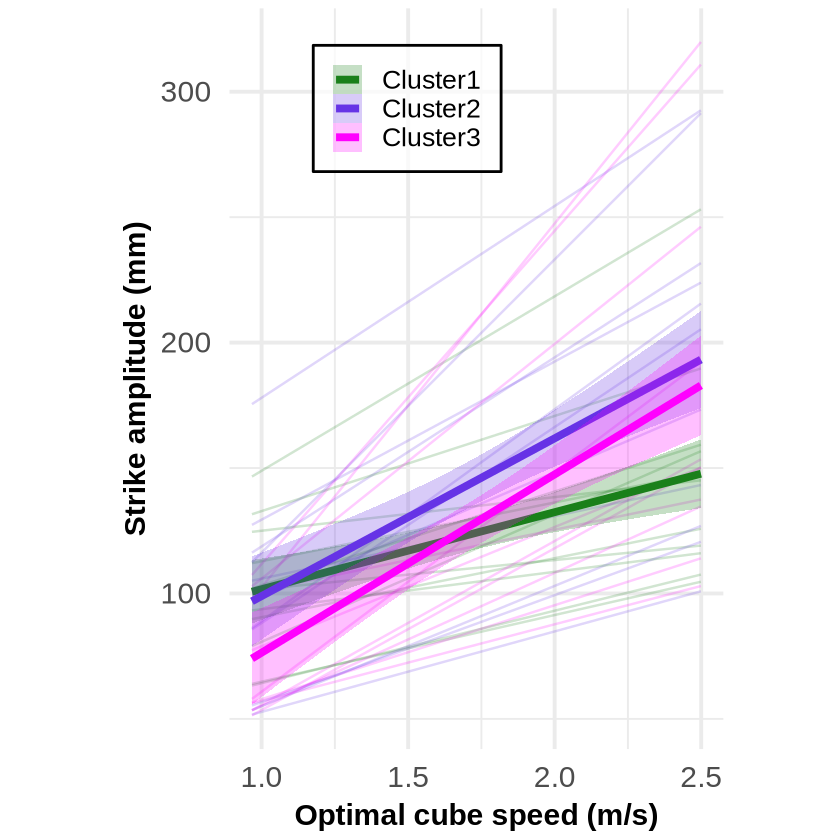

In [55]:
p1

# *Strike Duration* regression plot

In [56]:
dur_data <- subset(mydata, Measure == "Duration")

In [57]:
library(dplyr)
library(ggplot2)
#library(ggrepel)

#----------------------------------------------------------
# 1. FIT INDIVIDUAL PARTICIPANT LINES
#----------------------------------------------------------

preds <- dur_data %>%
  group_by(Participant, Cluster) %>%
  do({
    dd <- .
    if (length(unique(dd$Opti_Speed)) < 2) return(data.frame())
    mod <- lm(Mean ~ Opti_Speed, data = dd)
    xs <- seq(min(dd$Opti_Speed), max(dd$Opti_Speed), length.out = 50)
    data.frame(
      Opti_Speed = xs,
      Mean = predict(mod, newdata = data.frame(Opti_Speed = xs))
    )
  }) %>% 
  ungroup()

#----------------------------------------------------------
# 2. PLOT WITH COLORED CI RIBBONS 
#----------------------------------------------------------

p2 <- ggplot(dur_data, aes(x = Opti_Speed, y = Mean, color = Cluster)) +

  # (A) Transparent participant regression lines
  geom_line(data = preds,
            aes(group = Participant),
            alpha = 0.2, size = 0.7) +

  # (B) Cluster averages + cluster-colored confidence bands
  geom_smooth(aes(group = Cluster, fill = Cluster),
              method = "lm", se = TRUE,
              size = 2.2, alpha = 0.25) +

  scale_color_manual(values = c(
   "Cluster1" = "#1A801A", # dark green
    "Cluster2" = "#6633E6", # purple
    "Cluster3" = "#FF00FF" #magenta
  )) +
  scale_fill_manual(values = c(
    "Cluster1" = "#1A801A",
    "Cluster2" = "#6633E6",
    "Cluster3" = "#FF00FF"
  )) +

  labs(x = "Optimal cube speed (m/s)",
       y = "Strike duration (s)") +
  theme_minimal(base_size = 24) +
  theme(
    # Reduce size of the main axis labels/titles
    axis.title = element_text(size = 18, face = "bold"), 
    plot.margin = margin(5, 0, 5, 0, "pt"), # t, r, b, l. Left and Right margins are 0.
      
    # Reduce size of the tick mark numbers/text
    axis.text = element_text(size = 18),  
    
    # Adjust the legend title/text if needed (using 'common_legend' object)
    legend.title = element_text(size = 16), 
    legend.text = element_text(size = 16),
    
    aspect.ratio = 6/4,
    legend.position = "none" # Remove the legend for the final plot
  )



`geom_smooth()` using formula = 'y ~ x'


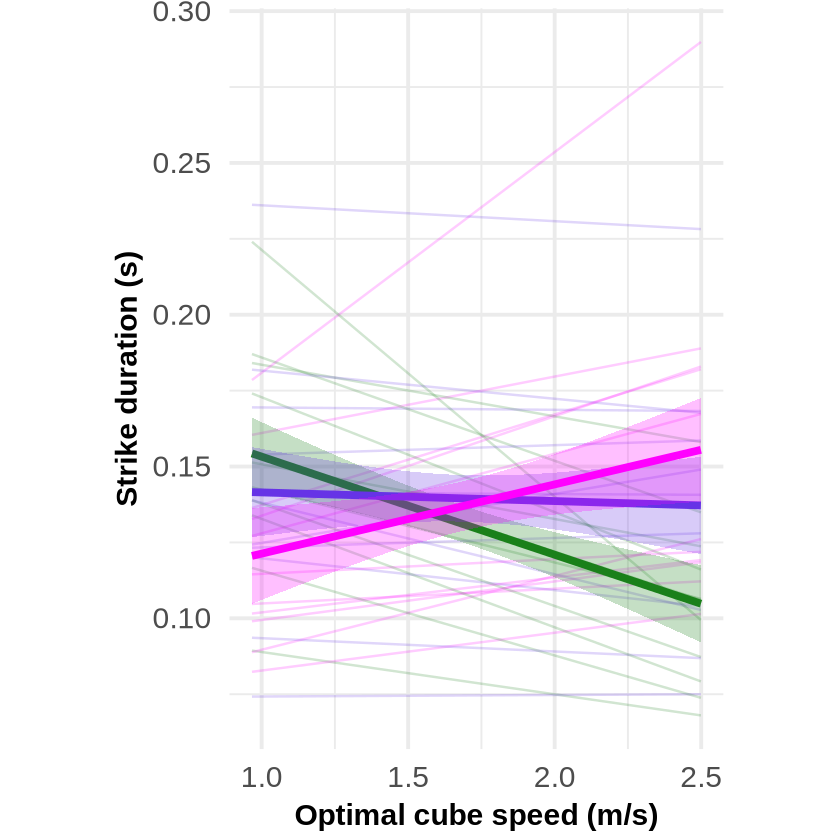

In [58]:
p2

# *Strike impact speed* regression plot

In [59]:
is_data <- subset(mydata, Measure == "Impact_Speed")

In [60]:
library(dplyr)
library(ggplot2)
#library(ggrepel)

#----------------------------------------------------------
# 1. FIT INDIVIDUAL PARTICIPANT LINES 
#----------------------------------------------------------

preds <- is_data %>%
  group_by(Participant, Cluster) %>%
  do({
    dd <- .
    if (length(unique(dd$Opti_Speed)) < 2) return(data.frame())
    mod <- lm(Mean ~ Opti_Speed, data = dd)
    xs <- seq(min(dd$Opti_Speed), max(dd$Opti_Speed), length.out = 50)
    data.frame(
      Opti_Speed = xs,
      Mean = predict(mod, newdata = data.frame(Opti_Speed = xs))
    )
  }) %>% 
  ungroup()

#----------------------------------------------------------
# 2. PLOT WITH COLORED CI RIBBONS 
#----------------------------------------------------------

p3 <-
ggplot(is_data, aes(x = Opti_Speed, y = Mean, color = Cluster)) +

  # (A) Transparent participant regression lines
  geom_line(data = preds,
            aes(group = Participant),
            alpha = 0.2, size = 0.7) +

  # (B) Cluster averages + cluster-colored confidence bands
  geom_smooth(aes(group = Cluster, fill = Cluster),
              method = "lm", se = TRUE,
              size = 2.2, alpha = 0.25) +

  scale_color_manual(values = c(
   "Cluster1" = "#1A801A", # dark green
    "Cluster2" = "#6633E6", # purple
    "Cluster3" = "#FF00FF" #magenta
  )) +
  scale_fill_manual(values = c(
    "Cluster1" = "#1A801A",
    "Cluster2" = "#6633E6",
    "Cluster3" = "#FF00FF"
  )) +

 labs(x = "Optimal cube speed (m/s)",
       y = "Strike impact speed (m/s)") +

  theme_minimal(base_size = 24) +

# === ADD THESE LINES FOR FINE CONTROL ===
  theme(
    # Reduce size of the main axis labels/titles
    axis.title = element_text(size = 18, face = "bold"), 
    plot.margin = margin(5, 5, 5, 0, "pt"), # t, r, b, l. Left margin is 0.
      
    # Reduce size of the tick mark numbers/text
    axis.text = element_text(size = 18),  
    
    # Adjust the legend title/text if needed (using 'common_legend' object)
    legend.title = element_text(size = 16), 
    legend.text = element_text(size = 16),
    
    aspect.ratio = 6/4,
    legend.position = "none" # Remove the legend for the final plot
  )



`geom_smooth()` using formula = 'y ~ x'


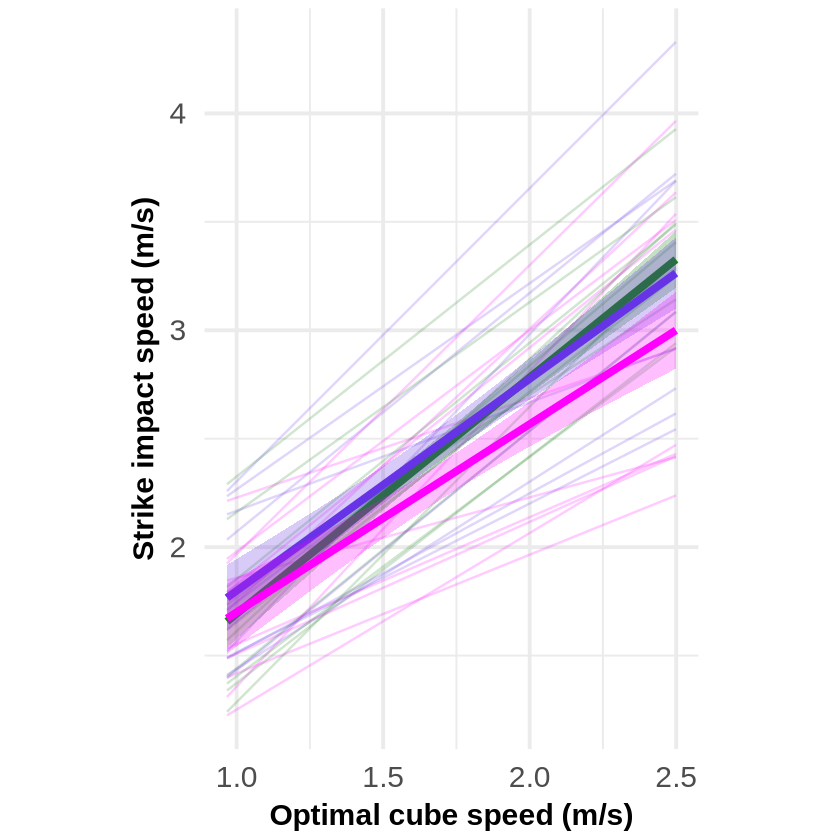

In [61]:
p3

In [62]:
install.packages("cowplot")
library(cowplot)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [63]:
p1 <- p1 + theme(aspect.ratio = 6/4)
p2 <- p2 + theme(aspect.ratio = 6/4)
p3 <- p3 + theme(aspect.ratio = 6/4)

`geom_smooth()` using formula = 'y ~ x'


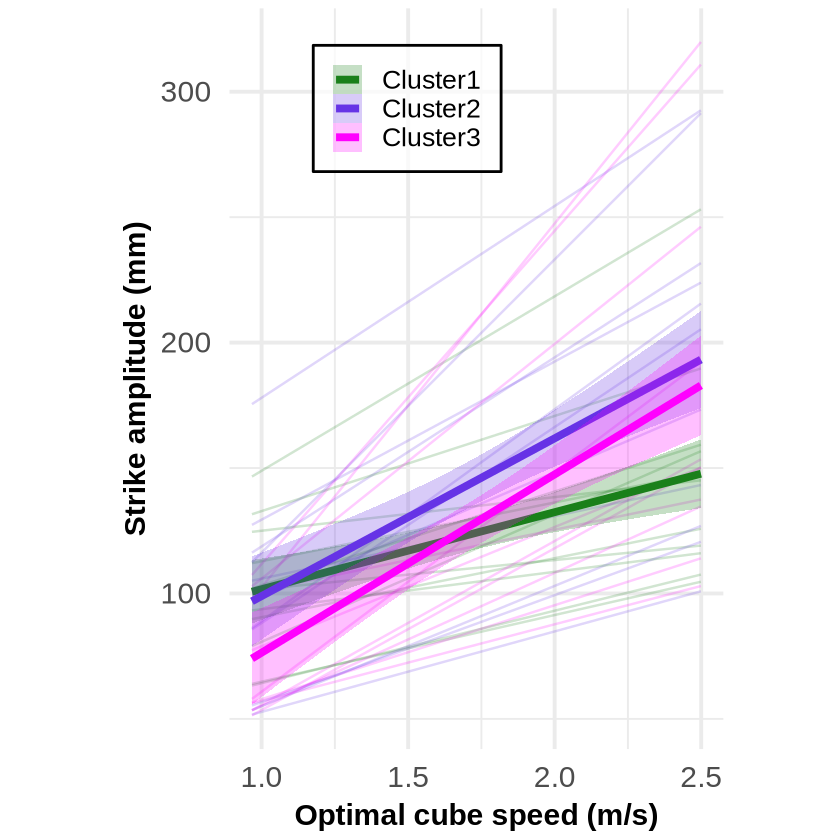

In [64]:
p1

# Code to generate a combined figure

In [65]:
install.packages("cowplot")
library(cowplot)

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



In [102]:
# --- 1. Define the final combination using NULL spacers ---
# We use two NULL placeholders for the space between p1/p2 and p2/p3.
combined_plot <- plot_grid(
  p1,
  NULL, # Spacer 1 (between p1 and p2)
  p2,
  NULL, # Spacer 2 (between p2 and p3)
  p3,
  
  # Total columns = 5 (3 plots + 2 spacers)
  ncol = 5,
  
  # Specify relative widths: 
  # 1 unit for each plot, and -0.05 units for each spacer (you can adjust -0.05)
  rel_widths = c(1, 0.05, 1, -0.04, 1),
  
  # Use strong alignment settings
  align = "hv", 
  axis = "lrtb"
)

# --- 2. Save the Plot ---
# Use save_plot with large dimensions
cowplot::save_plot(
  "combined_figure.png",
  combined_plot,
  base_height = 6, 
  base_width = 14 
)

cowplot::save_plot(
  "600dpi_combined_regression_figure.png",
  combined_plot,
  base_height = 6, 
  base_width = 14,
    dpi = 600
)

cowplot::save_plot(
  "1200dpi_combined_regression_figure.png",
  combined_plot,
  base_height = 6, 
  base_width = 14,
    dpi = 1200,
)

`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


In [67]:
install.packages("magick")

Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done



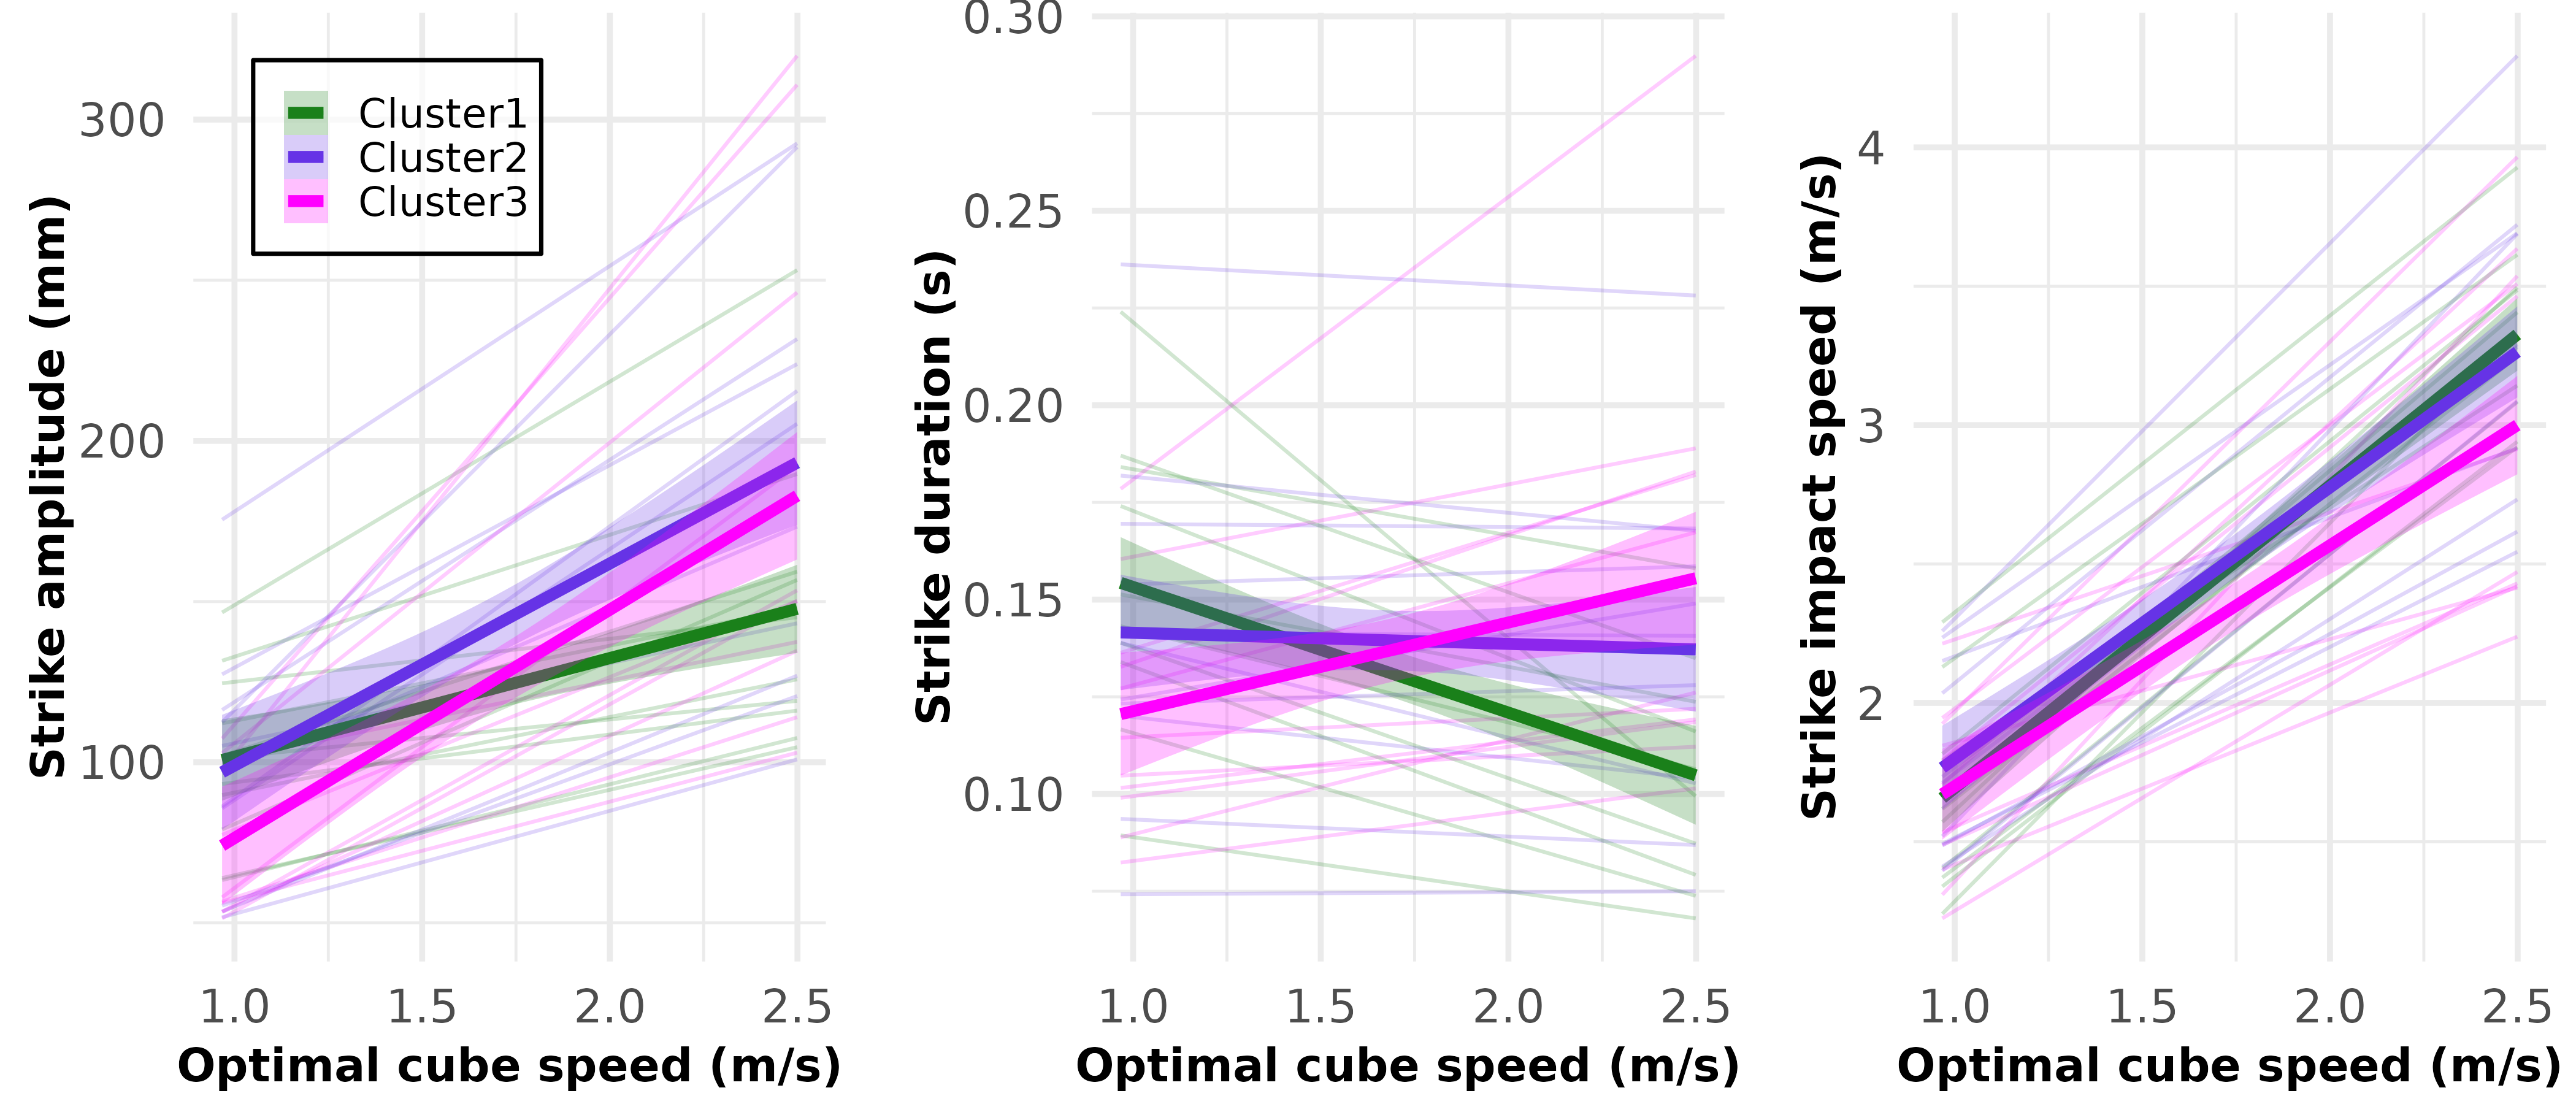

# A tibble: 1 × 7
  format width height colorspace matte filesize density  
  <chr>  <int>  <int> <chr>      <lgl>    <int> <chr>    
1 PNG     4200   1800 sRGB       TRUE   1058448 +118x+118


In [103]:
library(magick)
img <- magick::image_read('combined_figure.png')
print(img)

In [69]:

cowplot::save_plot(
  "600dpi_combined_regression_figure.eps",     
  combined_plot,
  base_height = 6, 
  base_width = 14,
  device = cairo_ps,             
  dpi = 600                  
)



# *Spatial error* regression plots

In [70]:
library(dplyr)

spat_err_data <- subset(mydata, Measure == "Spatial_Error")

In [71]:
spat_err_data

,Participant,Cluster,Measure,Opti_Speed,Mean
,<int>,<chr>,<chr>,<dbl>,<dbl>
100,10,Cluster1,Spatial_Error,0.967,-6.312
101,14,Cluster1,Spatial_Error,0.967,-9.910
102,16,Cluster1,Spatial_Error,0.967,-10.872
103,19,Cluster1,Spatial_Error,0.967,-9.158
104,20,Cluster1,Spatial_Error,0.967,20.662
105,27,Cluster1,Spatial_Error,0.967,12.356
106,29,Cluster1,Spatial_Error,0.967,1.421
107,37,Cluster1,Spatial_Error,0.967,16.202
108,41,Cluster1,Spatial_Error,0.967,-12.437


`geom_smooth()` using formula = 'y ~ x'
`geom_smooth()` using formula = 'y ~ x'


pdf 
  2

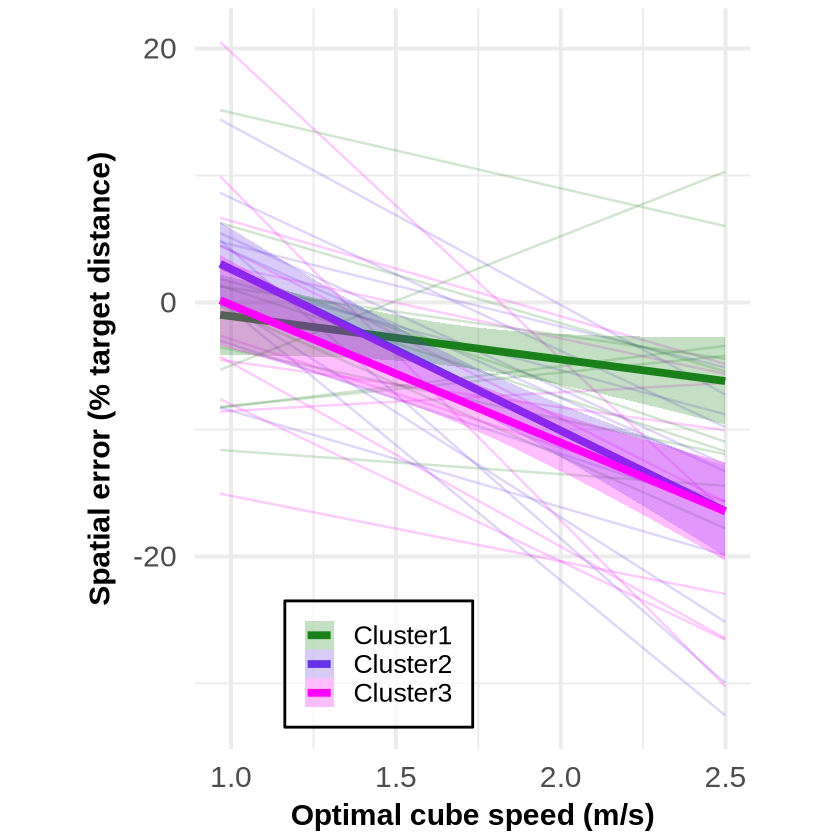

In [111]:
library(dplyr)
library(ggplot2)

# --- 1. Define COMMON DATA PROCESSING Function ---
generate_preds <- function(data) {
  data %>%
    group_by(Participant, Cluster) %>%
    do({
      dd <- .
      if (length(unique(dd$Opti_Speed)) < 2) return(data.frame())
      
      mod <- lm(Mean ~ Opti_Speed, data = dd)
      xs <- seq(min(dd$Opti_Speed), max(dd$Opti_Speed), length.out = 50)
      data.frame(
        Opti_Speed = xs,
        Mean = predict(mod, newdata = data.frame(Opti_Speed = xs))
      )
    }) %>% 
    ungroup()
}

# Define color palette
cluster_colors <- c(
  "Cluster1" = "#1A801A", # dark green
  "Cluster2" = "#6633E6", # purple
  "Cluster3" = "#FF00FF"  # magenta
)

# Define the common theme adjustments for text sizing (Y-axis elements remain visible)
theme_common_text <- theme(
  # Text size adjustments
  axis.title = element_text(size = 18, face = "bold"),
  axis.text = element_text(size = 18),
  legend.title = element_text(size = 16),
  legend.text = element_text(size = 16),
  
  # Fixed Aspect Ratio
  #aspect.ratio = 6/4,
    aspect.ratio = 8/6,
  
  # Set standard 5pt margins for all plots
  plot.margin = margin(5, 5, 5, 5, "pt")
)

# --- 2. Define PLOT 1 (p1) - Legend ON, Y-Axis ON ---
preds_p1 <- generate_preds(spat_err_data)

SpErrPlot <-
ggplot(spat_err_data, aes(x = Opti_Speed, y = Mean, color = Cluster)) +
  geom_line(data = preds_p1, aes(group = Participant), alpha = 0.2, size = 0.7) +
  geom_smooth(aes(group = Cluster, fill = Cluster), method = "lm", se = TRUE, size = 2.2, alpha = 0.25) +
  
  scale_color_manual(values = cluster_colors) +
  scale_fill_manual(values = cluster_colors) +
  
  labs(x = "Optimal cube speed (m/s)", y = "Spatial error (% target distance)") +
  theme_minimal(base_size = 24) + 
  theme_common_text + 
  theme(
    # P1 Specifics: Legend inside
    legend.title = element_blank(),
      legend.position = c(0.5, 0.2),
    legend.justification = c(1, 1),
    legend.background = element_rect(fill = alpha("white", 0.7), color = "black", linewidth = 0.8)
  )

SpErrPlot


png(
  filename = "600dpi_SpErrPlot.png",
        width = 6,
    height = 8,
     units = "in",
  res = 600
)

png(
  filename = "1200dpi_SpErrPlot.png",
        width = 6,
    height = 8,
     units = "in",
  res = 1200
)

print(SpErrPlot)

dev.off()

# Rainclouds plots (see Allen et al., 2021) on *Z* scored regression slopes
### https://github.com/RainCloudPlots/RainCloudPlots

In [112]:
# Load necessary libraries
library(dplyr)
library(tidyr)
library(purrr)
library(broom)


# --- Step 1: Run Linear Regression per Participant/Cluster/Measure ---
slopes_data <- mydata %>%
    # Group the data by the variables that define a unique model
    group_by(Participant, Cluster, Measure) %>%
    # Nest the remaining data (Opti_Speed and Mean) into a 'data' column
    nest() %>%
    
    # Run the linear model (lm) on the nested data and save the model object
    mutate(
        model = map(data, ~lm(Mean ~ Opti_Speed, data = .))
    ) %>%
    
    # --- Step 2: Extract the Slope Coefficient ---
    # Use broom::tidy to extract coefficients and other model statistics
    # 'map' ensures it runs on every model object
    mutate(
        tidy_model = map(model, tidy)
    ) %>%
    
    # Unnest the tidy_model results
    unnest(tidy_model) %>%
    
    # Filter to keep only the slope (coefficient for 'Opti_Speed')
    filter(term == "Opti_Speed") %>%
    
    # --- Step 3: Select and Rename Final Columns ---
    select(
        Participant,
        Cluster,
        Measure,
        # The slope is stored in the 'estimate' column
        slope = estimate
    ) %>%
    ungroup()

# Display the resulting data frame with the slopes
print(slopes_data)

# Save the resulting data frame for later use (e.g., Z-scoring)
write.csv(slopes_data, "slopes_per_participant.csv", row.names = FALSE)

# A tibble: 132 × 4
   Participant Cluster  Measure   slope
         <int> <chr>    <chr>     <dbl>
 1          10 Cluster1 Amplitude  23.4
 2          14 Cluster1 Amplitude  23.5
 3          16 Cluster1 Amplitude  26.6
 4          19 Cluster1 Amplitude  50.7
 5          20 Cluster1 Amplitude  69.5
 6          27 Cluster1 Amplitude  13.4
 7          29 Cluster1 Amplitude  37.9
 8          37 Cluster1 Amplitude  28.9
 9          41 Cluster1 Amplitude  11.6
10          44 Cluster1 Amplitude  37.4
# ℹ 122 more rows


In [113]:
slopes_data

Participant,Cluster,Measure,slope
<int>,<chr>,<chr>,<dbl>
10,Cluster1,Amplitude,23.41070
14,Cluster1,Amplitude,23.51184
16,Cluster1,Amplitude,26.57535
19,Cluster1,Amplitude,50.68848
20,Cluster1,Amplitude,69.53691
27,Cluster1,Amplitude,13.39864
29,Cluster1,Amplitude,37.93049
37,Cluster1,Amplitude,28.86720
41,Cluster1,Amplitude,11.58904


In [114]:
# Load necessary libraries
library(dplyr)

# R code to correctly Z-score the slope, grouped by Measure
final_zscored <- slopes_data %>%
    # 1. Group the data by Measure
    group_by(Measure) %>%
    # 2. Calculate the Z-score for the 'slope' column within each group
    # IMPORTANT: as.numeric() is necessary because scale() returns a matrix object
    mutate(Z_Slope = as.numeric(scale(slope))) %>%
    # 3. Ungroup the data
    ungroup()

# Verification step 
# This MUST show means very close to zero
final_zscored %>%
    group_by(Measure) %>%
    summarise(Mean_Z_Score_Check = mean(Z_Slope))

Measure,Mean_Z_Score_Check
<chr>,<dbl>
Amplitude,2.661881e-17
Duration,8.407495e-18
Impact_Speed,6.733676e-17
Spatial_Error,6.618890e-17


In [115]:
final_zscored

Participant,Cluster,Measure,slope,Z_Slope
<int>,<chr>,<chr>,<dbl>,<dbl>
10,Cluster1,Amplitude,23.41070,-0.9359540
14,Cluster1,Amplitude,23.51184,-0.9329460
16,Cluster1,Amplitude,26.57535,-0.8418386
19,Cluster1,Amplitude,50.68848,-0.1247240
20,Cluster1,Amplitude,69.53691,0.4358208
27,Cluster1,Amplitude,13.39864,-1.2337084
29,Cluster1,Amplitude,37.93049,-0.5041412
37,Cluster1,Amplitude,28.86720,-0.7736797
41,Cluster1,Amplitude,11.58904,-1.2875252


In [116]:
write.csv(final_zscored, "final_zscored.csv", row.names = FALSE)

In [117]:
zscore_data <- as.data.frame(final_zscored)

# Filter out the unwanted "Spatial_Error" Measure and set the factors
zscore_data_filtered <- zscore_data %>%
    filter(Measure %in% c("Amplitude", "Duration", "Impact_Speed")) %>%
    mutate(
        Measure = factor(Measure, levels = c("Amplitude", "Duration", "Impact_Speed")),
        Cluster = factor(Cluster, levels = c("Cluster1", "Cluster2", "Cluster3"))
    )

as.data.frame(zscore_data_filtered)

Participant,Cluster,Measure,slope,Z_Slope
<int>,<fct>,<fct>,<dbl>,<dbl>
10,Cluster1,Amplitude,23.41070,-0.9359540
14,Cluster1,Amplitude,23.51184,-0.9329460
16,Cluster1,Amplitude,26.57535,-0.8418386
19,Cluster1,Amplitude,50.68848,-0.1247240
20,Cluster1,Amplitude,69.53691,0.4358208
27,Cluster1,Amplitude,13.39864,-1.2337084
29,Cluster1,Amplitude,37.93049,-0.5041412
37,Cluster1,Amplitude,28.86720,-0.7736797
41,Cluster1,Amplitude,11.58904,-1.2875252


In [118]:
# Execute the script to load the function definition
source("summarySE.R")

In [119]:
sumrepdat <- summarySE(zscore_data_filtered, measurevar = "Z_Slope", 
                       groupvars=c("Measure", "Cluster"))

In [120]:
sumrepdat

Measure,Cluster,N,Z_Slope_mean,Z_Slope_median,sd,sem,ci
<fct>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Amplitude,Cluster1,11,-0.718901139,-0.8418386,0.5188878,0.1564506,0.3485936
Amplitude,Cluster2,11,0.238027631,0.2422941,0.7947757,0.2396339,0.5339376
Amplitude,Cluster3,11,0.480873508,0.2858301,1.1890754,0.3585197,0.7988317
Duration,Cluster1,11,-1.014970484,-0.9994289,0.6553364,0.1975914,0.4402610
Duration,Cluster2,11,0.045571144,0.1203191,0.3580781,0.1079646,0.2405601
Duration,Cluster3,11,0.969399340,0.8178229,0.6878515,0.2073950,0.4621049
Impact_Speed,Cluster1,11,0.387775202,0.3153838,0.4558243,0.1374362,0.3062269
Impact_Speed,Cluster2,11,-0.002786751,0.1317838,0.9526926,0.2872476,0.6400276
Impact_Speed,Cluster3,11,-0.384988451,-0.5700431,1.3251974,0.3995620,0.8902797


In [121]:
source("geom_flat_violin.R")

Warning message in geom_line(data = sumrepdat, aes(x = as.numeric(Measure) + 0.08, :
“Ignoring unknown aesthetics: Measure”
Warning message in geom_point(data = sumrepdat, aes(x = as.numeric(Measure) + 0.08, :
“Ignoring unknown aesthetics: Measure”
Warning message in geom_errorbar(data = sumrepdat, aes(x = as.numeric(Measure) + :
“Ignoring unknown aesthetics: Measure”
Scale for colour is already present.
Adding another scale for colour, which will replace the existing scale.
Scale for fill is already present.
Adding another scale for fill, which will replace the existing scale.


<ggproto object: Class CoordFlip, CoordCartesian, Coord, gg>
    aspect: function
    backtransform_range: function
    clip: on
    default: FALSE
    distance: function
    draw_panel: function
    expand: TRUE
    is_free: function
    is_linear: function
    labels: function
    limits: list
    modify_scales: function
    range: function
    render_axis_h: function
    render_axis_v: function
    render_bg: function
    render_fg: function
    reverse: none
    setup_data: function
    setup_layout: function
    setup_panel_guides: function
    setup_panel_params: function
    setup_params: function
    train_panel_guides: function
    transform: function
    super:  <ggproto object: Class CoordFlip, CoordCartesian, Coord, gg>

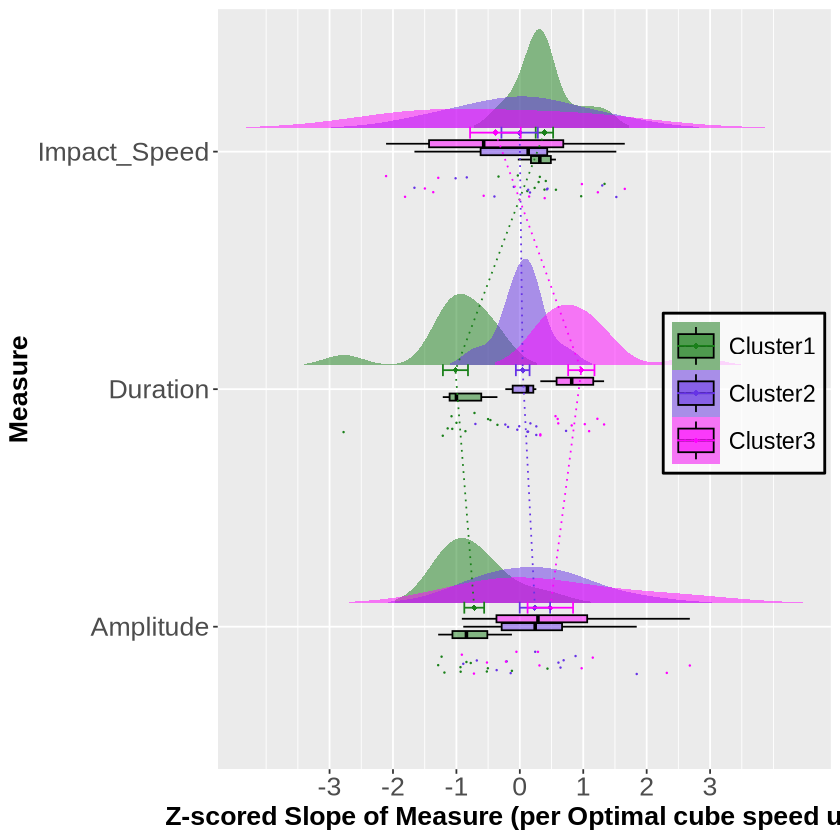

In [122]:
# See "Rainclouds for repeated measures, additional plotting options" in Allen et al (2021)

# Define w and h for ggsave (e.g., in inches)
w <- 10
h <- 6

p12 <- ggplot(zscore_data_filtered, aes(x = Measure, y = Z_Slope, fill = Cluster)) +   
geom_flat_violin(aes(fill = Cluster),position = position_nudge(x = .1, y = 0), 
                 adjust = 1.5, trim = FALSE, alpha = .5, colour = NA)+   
geom_point(aes(x = as.numeric(Measure)-.15, y = Z_Slope, colour = Cluster),position = position_jitter(width = .05), size = .25, shape = 20)+   
geom_boxplot(aes(x = Measure, y = Z_Slope, fill = Cluster),outlier.shape = NA, alpha = .5, width = .1, colour = "black")+   
geom_line(data = sumrepdat, aes(x = as.numeric(Measure)+.08, y = Z_Slope_mean, Measure = Cluster, colour = Cluster), linetype = 3)+   
geom_point(data = sumrepdat, aes(x = as.numeric(Measure)+.08, y = Z_Slope_mean, Measure = Cluster, colour = Cluster), shape = 18) +   
geom_errorbar(data = sumrepdat, aes(x = as.numeric(Measure)+.08, y = Z_Slope_mean, Measure = Cluster, colour = Cluster, ymin = Z_Slope_mean-sem, ymax = Z_Slope_mean+sem), width = .05)+   
scale_y_continuous(breaks = seq(-3, 3, by = 1))+
scale_colour_brewer(palette = "Dark2")+   scale_fill_brewer(palette = "Dark2")+   
coord_flip()   +
#ggtitle("Figure R12: Repeated Measures - Factorial (Extended)") +  
  theme(
          axis.text  = element_text(size = 16),
    axis.title = element_text(size = 16, face = "bold"),
  #  legend.title = element_text(size = 16, face = "bold"),
         legend.title = element_blank(),
    legend.text  = element_text(size = 14),
    legend.key.size = unit(1, "cm"),
    plot.title = element_text(size = 18),
      legend.position = c(0.99, 0.6),   # inside the plot
    #  legend.position = "none",
    legend.justification = c(1, 1),
    legend.background = element_rect(
    fill = alpha("white", 0.7),   # background
    color = "black",              # <-- frame/border
    linewidth = 0.8               # thickness of the frame
  ) 
      )+
        labs(x = "Measure",
       y = "Z-scored Slope of Measure (per Optimal cube speed unit)") +

 
scale_color_manual(values = c(
   "Cluster1" = "#1A801A", # dark green
    "Cluster2" = "#6633E6", # purple
    "Cluster3" = "#FF00FF" #magenta
  )) +
  scale_fill_manual(values = c(
    "Cluster1" = "#1A801A",
    "Cluster2" = "#6633E6",
    "Cluster3" = "#FF00FF"
  ))
coord_flip()   

ggsave('zscored_slopes.png', width = w, height = h)

ggsave('600dpi_zscored_slopes.png', width = w, height = h, dpi = 600)

ggsave('1200dpi_zscored_slopes.png', width = w, height = h, dpi = 1200)

ggsave("600dpi_zscored_slopes.eps", 
       p12, 
       device = cairo_ps, 
       width = w, 
       height = h, 
       units = "in",
       dpi = 600)

p12